In [2]:
# 必要なライブラリのインポート
import pandas as pd

# transaction_history.csvをData Frameに読み込み
transaction_history = pd.read_csv('../data/transaction_history.csv', dtype={'customer_id': str})

# customer_idごとにpurchase_amountの合計を計算
customer_purchase_sum = transaction_history.groupby('customer_id')['purchase_amount'].sum().reset_index()

# 結果の表示
customer_purchase_sum.head()

,customer_id,purchase_amount
0,00010000,9300
1,00010001,8300
2,00010002,164700
3,00010003,46000
4,00010004,69300


In [3]:
# 分位点（5分割：20%ごと）を計算
quantiles = customer_purchase_sum['purchase_amount'].quantile([0.2, 0.4, 0.6, 0.8])

# ランク付け関数の定義
def categorize_purchase(amount):
    if amount <= quantiles[0.2]:
        return 'Very Low'
    elif amount <= quantiles[0.4]:
        return 'Low'
    elif amount <= quantiles[0.6]:
        return 'Medium'
    elif amount <= quantiles[0.8]:
        return 'High'
    else:
        return 'Very High'

# ランク列の追加
customer_purchase_sum['purchase_rank'] = customer_purchase_sum['purchase_amount'].apply(categorize_purchase)

# 結果の確認
customer_purchase_sum.head()

,customer_id,purchase_amount,purchase_rank
0,00010000,9300,Very Low
1,00010001,8300,Very Low
2,00010002,164700,High
3,00010003,46000,Low
4,00010004,69300,Medium


/var/folders/0t/6d51btm11zz6lw61fgrmf7z00000gn/T/ipykernel_58650/618109133.py:33: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) AppleGothic.
  plt.tight_layout()
/Users/maton/.pyenv/versions/3.10.13/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


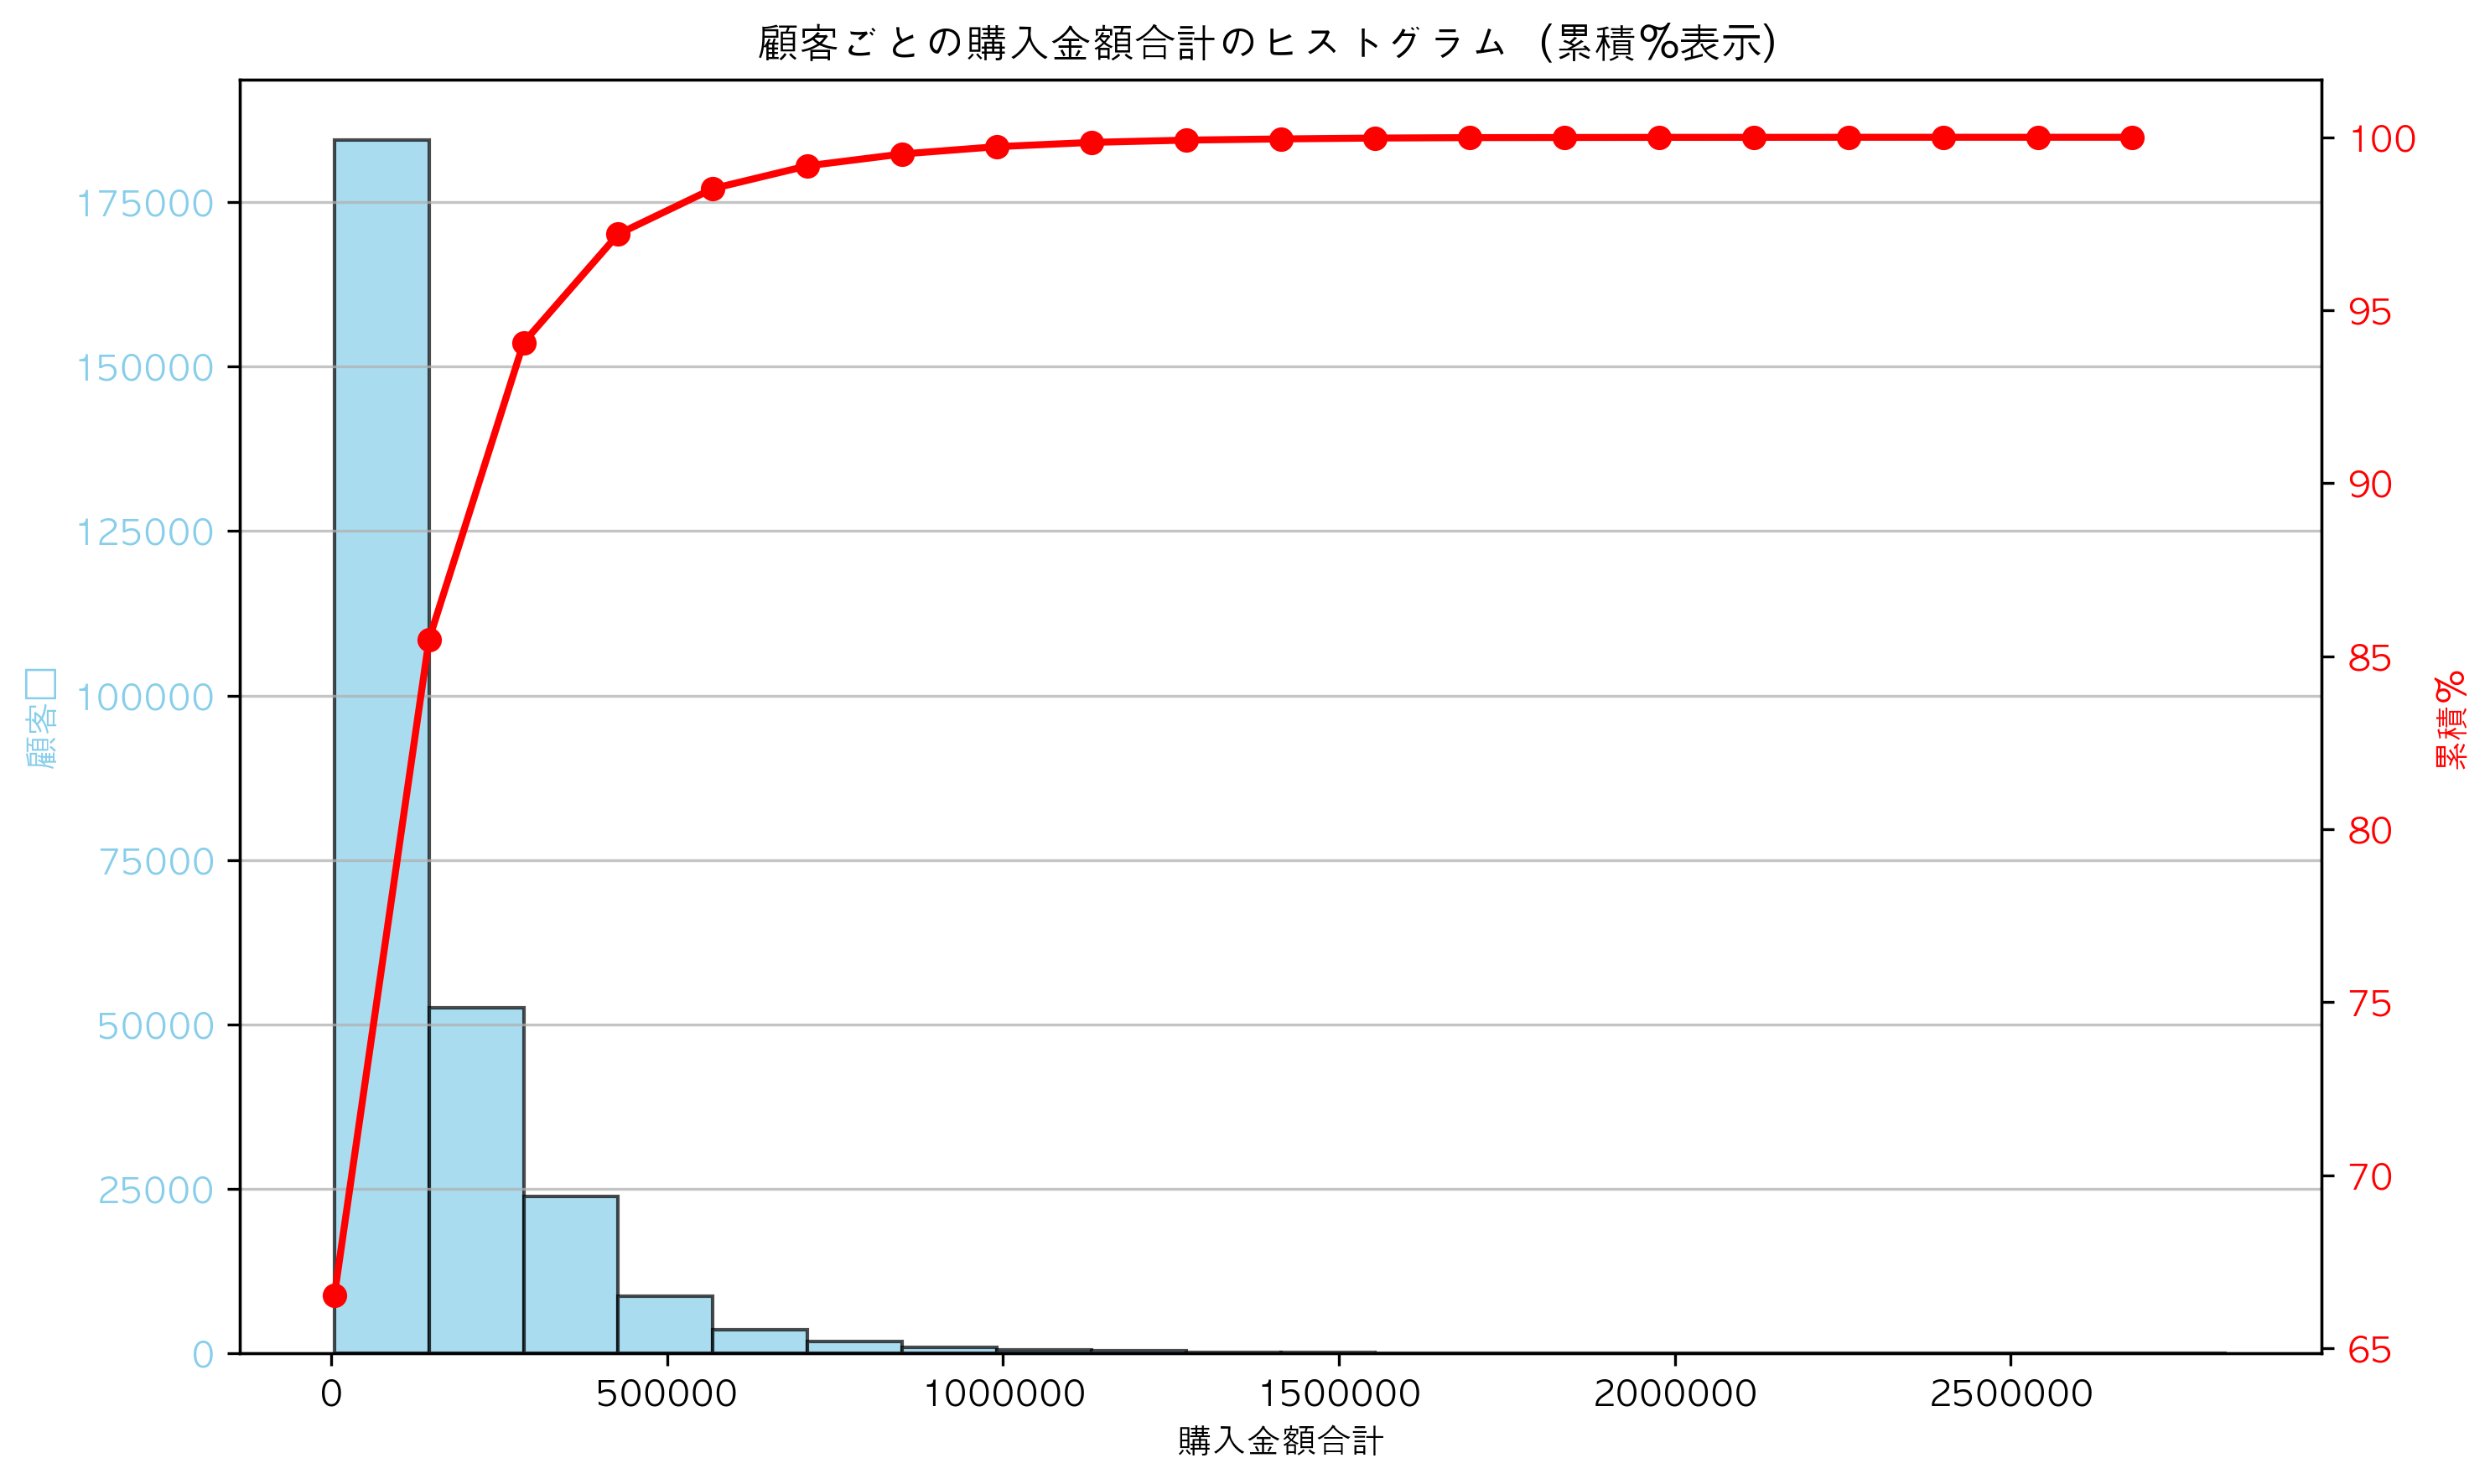

In [6]:
# Monetary（顧客ごとの購入金額合計）の分布を可視化
import numpy as np
# グラフの日本語表記
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "AppleGothic"  # macOS向け

# データ準備
values = customer_purchase_sum["purchase_amount"]
hist, bins = np.histogram(values, bins=20)
cumulative_percentage = np.cumsum(hist) / np.sum(hist) * 100

# プロット
fig, ax1 = plt.subplots(figsize=(10, 6), dpi=300)

# ヒストグラム（左軸）
ax1.hist(values, bins=bins, color="skyblue", edgecolor="black", alpha=0.7)
ax1.set_xlabel("購入金額合計")
ax1.set_ylabel("顧客数", color="skyblue")
ax1.tick_params(axis="y", labelcolor="skyblue")
ax1.grid(axis="y", alpha=0.75)
ax1.ticklabel_format(style="plain", axis="x")
# 累積％（右軸）
ax2 = ax1.twinx()
ax2.plot(bins[:-1], cumulative_percentage, color="red", marker="o", linewidth=2)
ax2.set_ylabel("累積％", color="red")
ax2.tick_params(axis="y", labelcolor="red")

# タイトル
plt.title("顧客ごとの購入金額合計のヒストグラム（累積％表示）")

# 表示
plt.tight_layout()
plt.show()

/var/folders/0t/6d51btm11zz6lw61fgrmf7z00000gn/T/ipykernel_58650/106184166.py:50: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) AppleGothic.
  plt.tight_layout()


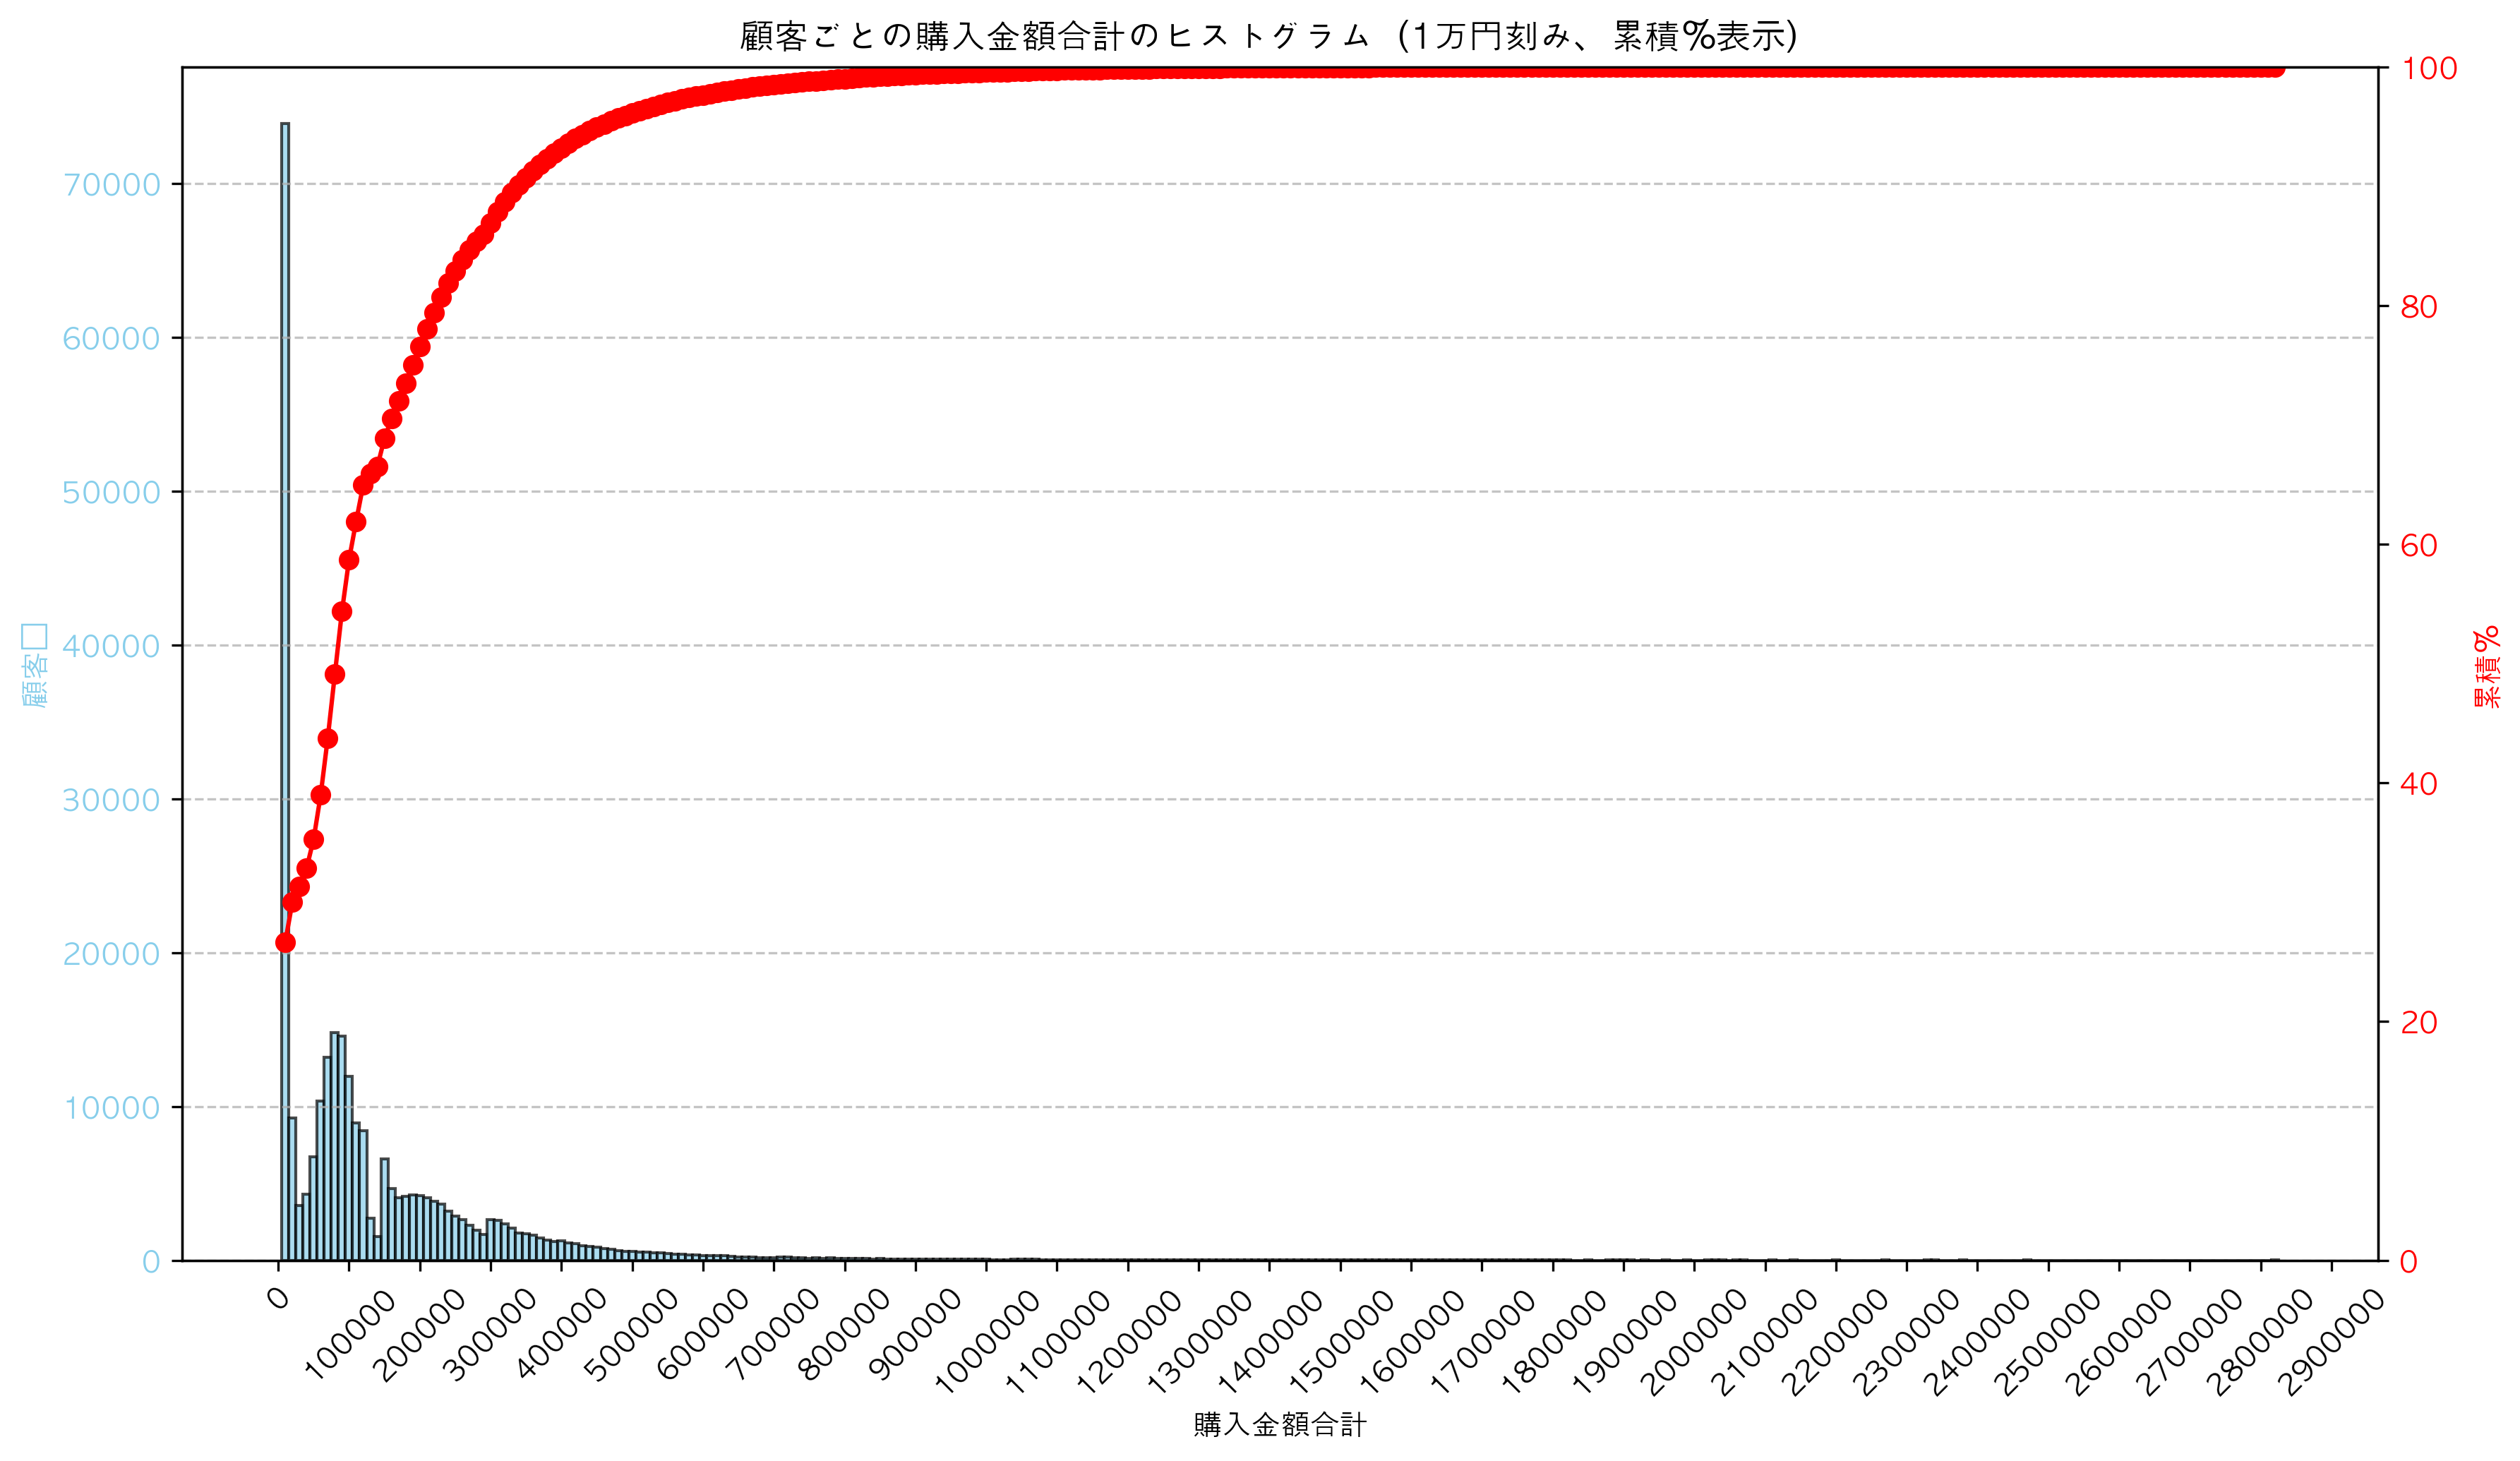

In [7]:
# 顧客ごとの購入金額合計のヒストグラムを10000円刻みで描画
# ヒストグラムのデータ準備
values = customer_purchase_sum["purchase_amount"]

# ビンの設定 (10000円刻み)
bin_width = 10000
# 最小値から最大値までの範囲でビンを作成
bins = np.arange(min(values), max(values) + bin_width, bin_width)

# 2軸グラフの作成
fig, ax1 = plt.subplots(figsize=(12, 7), dpi=300)

# Import ticker module
import matplotlib.ticker as ticker

# ヒストグラムのプロット (左軸)
hist, bins, patches = ax1.hist(
    values, bins=bins, color="skyblue", edgecolor="black", alpha=0.7
)
ax1.xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=False))
ax1.ticklabel_format(style="plain", axis="x")
ax1.set_xlabel("購入金額合計")
ax1.set_ylabel("顧客数", color="skyblue")
ax1.tick_params(axis="y", labelcolor="skyblue")
ax1.grid(axis="y", alpha=0.75, linestyle="--")

# 累積％の計算
cumulative_percentage = np.cumsum(hist) / np.sum(hist) * 100

# ビンの中心を計算して累積％のx座標とする
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# 累積％のプロット (右軸)
ax2 = ax1.twinx()
ax2.plot(bin_centers, cumulative_percentage, color="red", marker="o", linestyle="-")
ax2.set_ylabel("累積％", color="red")
ax2.tick_params(axis="y", labelcolor="red")
ax2.set_ylim(0, 100)  # 累積％なので0から100の範囲に固定

# x軸の目盛りを調整 (オプション)
# 10万円ごとに目盛りを表示する場合
max_amount = max(values)
ax1.set_xticks(np.arange(0, max_amount + 100000, 100000))
ax1.tick_params(axis="x", rotation=45)

# グラフタイトルの設定
plt.title("顧客ごとの購入金額合計のヒストグラム（1万円刻み、累積％表示）")

# レイアウトの調整
plt.tight_layout()

# グラフ表示
plt.show()

In [8]:
# 金額階級ごとにランク名を付与しdf_M_RankにM_Rankという名称で格納
def categorize_monetary(amount):
    if amount <= 10000:
        return "Very Low"
    elif amount <= 50000:
        return "Low"
    elif amount <= 100000:
        return "Medium"
    elif amount <= 300000:
        return "High"
    else:
        return "Very High"


customer_purchase_sum["M_Rank"] = customer_purchase_sum["purchase_amount"].apply(
    categorize_monetary
)
customer_purchase_sum.head()

,customer_id,purchase_amount,purchase_rank,M_Rank
0,00010000,9300,Very Low,Very Low
1,00010001,8300,Very Low,Very Low
2,00010002,164700,High,High
3,00010003,46000,Low,Low
4,00010004,69300,Medium,Medium


In [9]:
import pandas as pd

# データの読み込み
product_master = pd.read_csv("../data/product_master.csv")

# ワンホットエンコーディング
city_dummies = pd.get_dummies(product_master["destination_city"])

# product_idと結合
product_city_onehot = pd.concat([product_master[["product_id"]], city_dummies], axis=1)

# product_idごとに集計（都市が複数あれば1つでもあれば1）
product_city_onehot = product_city_onehot.groupby("product_id").max().reset_index()

# True/Falseを1/0に変換
product_city_onehot.iloc[:, 1:] = product_city_onehot.iloc[:, 1:].astype(int)

# 結果表示
product_city_onehot.head()

/var/folders/0t/6d51btm11zz6lw61fgrmf7z00000gn/T/ipykernel_58650/3366362949.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0         0
1         0
2         0
3         0
4         0
         ..
199995    0
199996    0
199997    0
199998    0
199999    0
Name: アブダビ, Length: 200000, dtype: int64' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  product_city_onehot.iloc[:, 1:] = product_city_onehot.iloc[:, 1:].astype(int)
/var/folders/0t/6d51btm11zz6lw61fgrmf7z00000gn/T/ipykernel_58650/3366362949.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0         0
1         0
2         0
3         0
4         0
         ..
199995    0
199996    0
199997    0
199998    0
199999    0
Name: シドニー, Length: 200000, dtype: int64' has dtype incompatible with bool, please explicitly cast to a compatible dtype first

,product_id,アブダビ,シドニー,シンガポール,ソウル,ドバイ,ニューヨーク,バンコク,パリ,ロンドン,...,旭川,松山,熊本,秋田,那覇,長崎,青森,静岡,香港,高松
0,0007ZNVK,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,000BK3XO,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,000G65QI,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,000KJZQ9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,000MRQW8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [10]:
# 6章で集計した最新購買日を改めて算出します
# purchase_dateをdatetime型に変換, エラーになる場合は無視して処理を続行
transaction_history["purchase_date"] = pd.to_datetime(
    transaction_history["purchase_date"], errors="coerce"
)

# エラーになる行を確認 (purchase_dateがNaTになっている行)
error_rows = transaction_history[transaction_history["purchase_date"].isnull()]
# print(f"Error rows:\n{error_rows}") ここは必要に応じて実行

# customer_idごとにpurchase_dateの最新日付を取得
latest_purchase_dates = (
    transaction_history.groupby("customer_id")["purchase_date"].max().reset_index()
)

# 最新購入日を取得
max_date = latest_purchase_dates["purchase_date"].max()

# 各行の日付から最新日との差（日数）を計算 max_dateはログデータ内の最新の日付
latest_purchase_dates["経過日数"] = (
    max_date - latest_purchase_dates["purchase_date"]
).dt.days

# 結果表示
latest_purchase_dates.head()

,customer_id,purchase_date,経過日数
0,00010000,2018-11-30,2199.0
1,00010001,2021-10-18,1146.0
2,00010002,2018-01-15,2518.0
3,00010003,2018-03-27,2447.0
4,00010004,2024-12-07,0.0


In [11]:
# 6章で集計した最新購買日を改めて算出します
# purchase_dateをdatetime型に変換, エラーになる場合は無視して処理を続行
transaction_history["purchase_date"] = pd.to_datetime(
    transaction_history["purchase_date"], errors="coerce"
)

# エラーになる行を確認 (purchase_dateがNaTになっている行)
error_rows = transaction_history[transaction_history["purchase_date"].isnull()]
# print(f"Error rows:\n{error_rows}") ここは必要に応じて実行

# customer_idごとにpurchase_dateの最新日付を取得
latest_purchase_dates = (
    transaction_history.groupby("customer_id")["purchase_date"].max().reset_index()
)

# 結果を表示
latest_purchase_dates.head()

,customer_id,purchase_date
0,00010000,2018-11-30
1,00010001,2021-10-18
2,00010002,2018-01-15
3,00010003,2018-03-27
4,00010004,2024-12-07


In [12]:
import pandas as pd

# データフレームの作成
data = {
    "datetime": ["2023-06-01 14:23:45", "2023-06-02 16:15:22", "2023-06-03 09:05:10"]
}
df = pd.DataFrame(data)

# datetime型に変換
df["datetime"] = pd.to_datetime(df["datetime"])

# 日付部分を抽出
df["date"] = df["datetime"].dt.date

# 結果の表示
df

,datetime,date
0,2023-06-01 14:23:45,2023-06-01
1,2023-06-02 16:15:22,2023-06-02
2,2023-06-03 09:05:10,2023-06-03


In [13]:
# 最新購入日を取得
max_date = latest_purchase_dates["purchase_date"].max()

# 各行の日付から最新日との差（日数）を計算 max_dateはログデータ内の最新の日付
latest_purchase_dates["経過日数"] = (
    max_date - latest_purchase_dates["purchase_date"]
).dt.days

# 結果表示
latest_purchase_dates.head()

,customer_id,purchase_date,経過日数
0,00010000,2018-11-30,2199.0
1,00010001,2021-10-18,1146.0
2,00010002,2018-01-15,2518.0
3,00010003,2018-03-27,2447.0
4,00010004,2024-12-07,0.0
